In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/interim/merged_external_dataset.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

df.head()

,price,actual_load,actual_residual_load,forecasted_load,forecasted_residual_load,actual_biomass,actual_hydropower,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_lignite,actual_hard_coal,actual_fossil_gas,actual_wind_total,forecasted_solar_wind_total,forecasted_wind_offshore,forecasted_wind_onshore,forecasted_solar,forecasted_wind_total
timestamp,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,-5.17,38346.00,6337.75,41792.50,2798.75,4014.25,1275.25,3059.25,28947.25,1.75,3859.25,2067.50,1593.75,32006.50,38993.75,3478.25,35515.50,0.0,38993.75
2023-01-01 01:00:00,-1.07,37777.25,4601.75,39621.00,886.25,3993.25,1226.50,3586.00,29587.50,2.00,3866.50,2052.00,1437.00,33173.50,38734.75,3390.25,35344.50,0.0,38734.75
2023-01-01 02:00:00,-1.47,36939.75,3581.00,38240.75,-293.50,3967.25,1222.50,3842.25,29514.75,1.75,3860.25,2034.25,1435.00,33357.00,38534.25,3395.50,35138.75,0.0,38534.25
2023-01-01 03:00:00,-5.08,35932.50,4973.75,37205.50,-645.75,3973.00,1223.25,3463.25,27493.50,2.00,3864.75,2037.00,1432.50,30956.75,37851.25,3410.25,34441.00,0.0,37851.25
2023-01-01 04:00:00,-4.49,35486.25,5082.75,37326.75,-2.50,3996.50,1244.00,3462.25,26939.00,2.25,3841.00,2040.25,1430.75,30401.25,37329.25,3431.25,33898.00,0.0,37329.25


In [12]:
df["actual_fossil_total"] = (
    df["actual_lignite"] +
    df["actual_hard_coal"] +
    df["actual_fossil_gas"]
)

df[[
    "price",
    "actual_residual_load",
    "actual_wind_total",
    "actual_solar",
    "actual_fossil_total"
]].describe()

,price,actual_residual_load,actual_wind_total,actual_solar,actual_fossil_total
count,27261.000000,27261.000000,27261.000000,27261.000000,27261.000000
mean,88.466876,30083.146202,15946.086284,7139.383026,18611.168460
std,51.000301,14098.837604,11212.287869,11076.965535,8771.277293
min,-500.000000,-8443.140000,46.500000,1.250000,4158.750000
25%,66.420000,20322.560000,6729.750000,6.750000,11574.500000
50%,90.970000,30576.250000,13400.530000,185.000000,17266.250000
75%,113.630000,39846.750000,23092.500000,11179.000000,24371.750000
max,936.280000,68275.750000,52875.500000,52132.250000,45739.750000


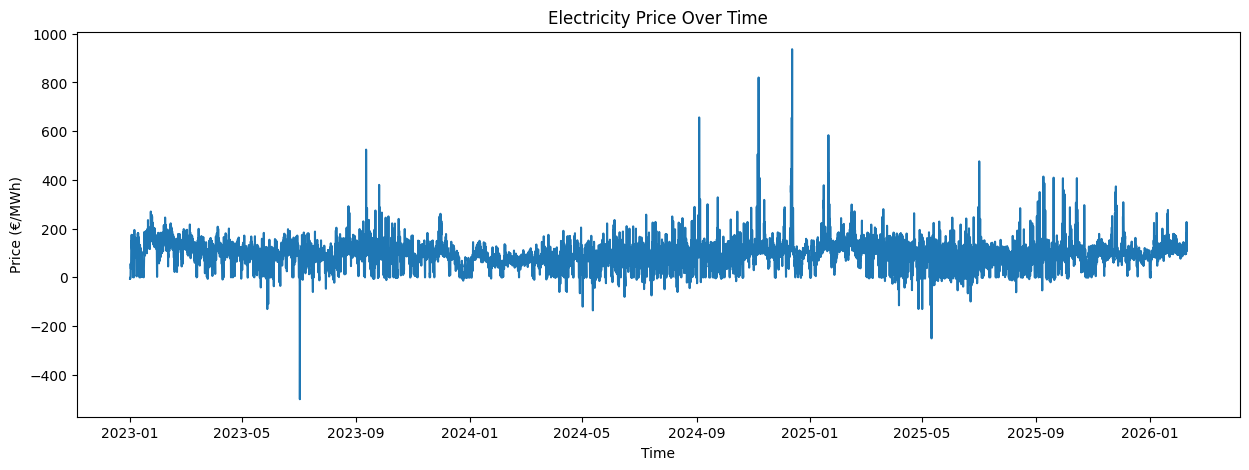

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["price"])
plt.title("Electricity Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (€/MWh)")
plt.show()

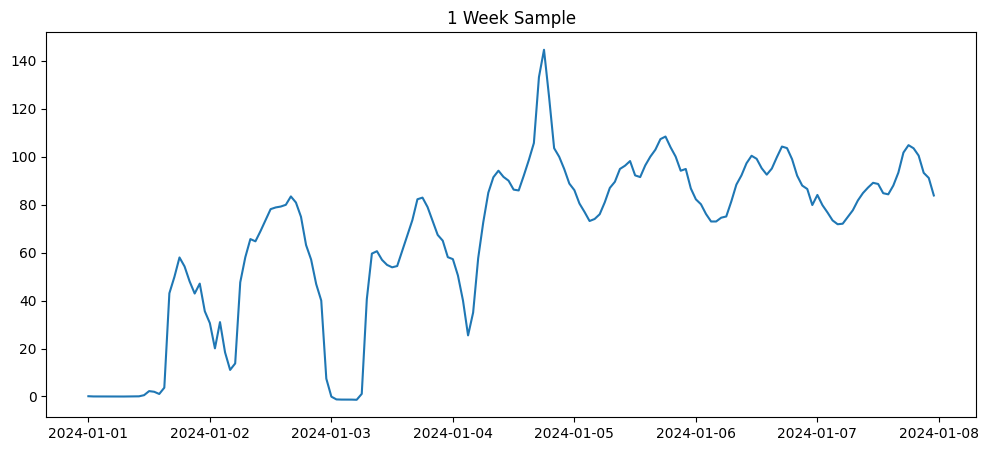

In [5]:
df_sample = df["2024-01-01":"2024-01-07"]

plt.figure(figsize=(12,5))
plt.plot(df_sample.index, df_sample["price"])
plt.title("1 Week Sample")
plt.show()

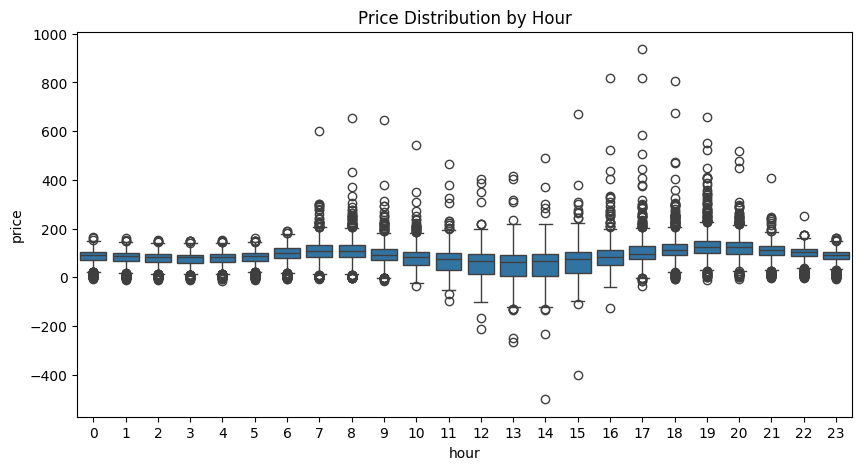

In [6]:
df["hour"] = df.index.hour

plt.figure(figsize=(10,5))
sns.boxplot(x="hour", y="price", data=df)
plt.title("Price Distribution by Hour")
plt.show()

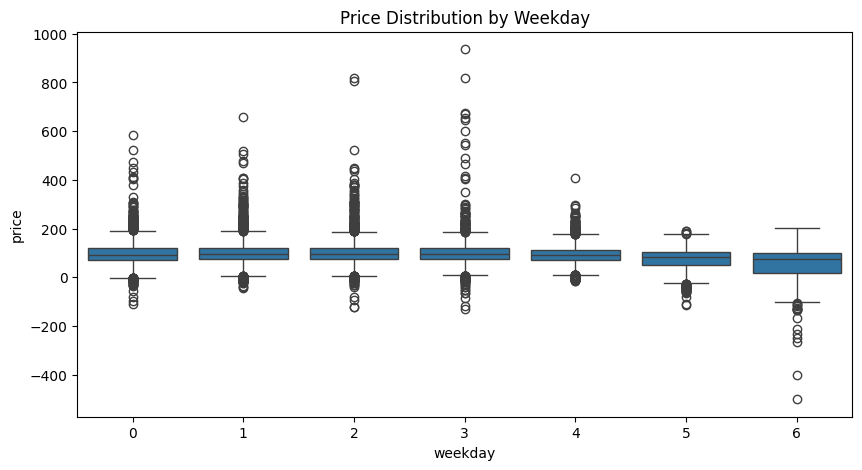

In [7]:
df["weekday"] = df.index.dayofweek

plt.figure(figsize=(10,5))
sns.boxplot(x="weekday", y="price", data=df)
plt.title("Price Distribution by Weekday")
plt.show()

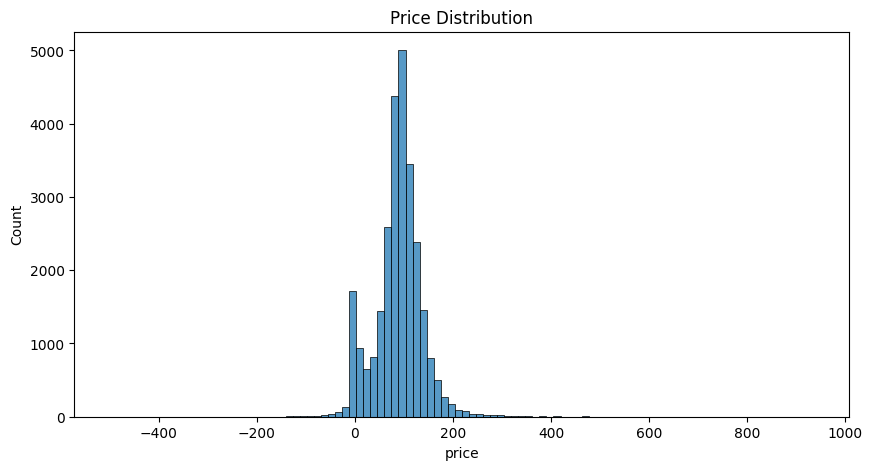

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=100)
plt.title("Price Distribution")
plt.show()

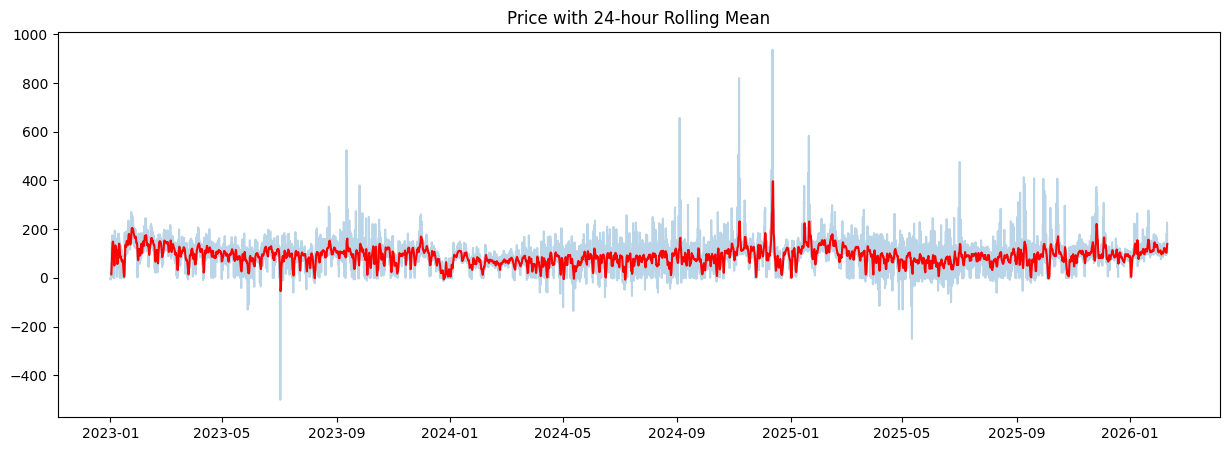

In [9]:
df["rolling_mean_24"] = df["price"].rolling(window=24).mean()

plt.figure(figsize=(15,5))
plt.plot(df.index, df["price"], alpha=0.3)
plt.plot(df.index, df["rolling_mean_24"], color="red")
plt.title("Price with 24-hour Rolling Mean")
plt.show()

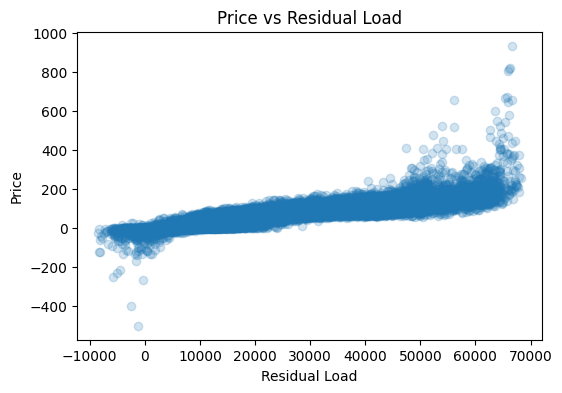

In [13]:
## After adding extrenal features, i did this part of the code
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df["actual_residual_load"], df["price"], alpha=0.2)

plt.xlabel("Residual Load")
plt.ylabel("Price")
plt.title("Price vs Residual Load")

plt.show()



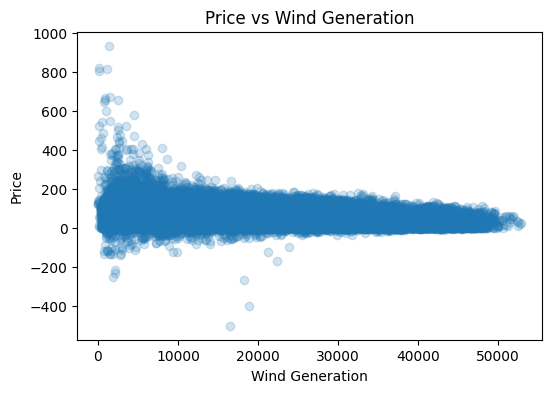

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(df["actual_wind_total"], df["price"], alpha=0.2)

plt.xlabel("Wind Generation")
plt.ylabel("Price")
plt.title("Price vs Wind Generation")

plt.show()

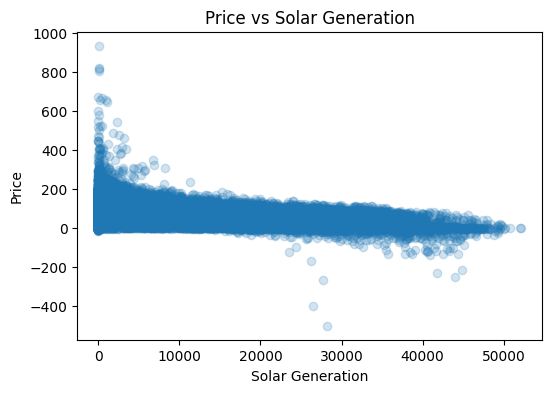

In [15]:
plt.figure(figsize=(6,4))

plt.scatter(df["actual_solar"], df["price"], alpha=0.2)

plt.xlabel("Solar Generation")
plt.ylabel("Price")
plt.title("Price vs Solar Generation")

plt.show()

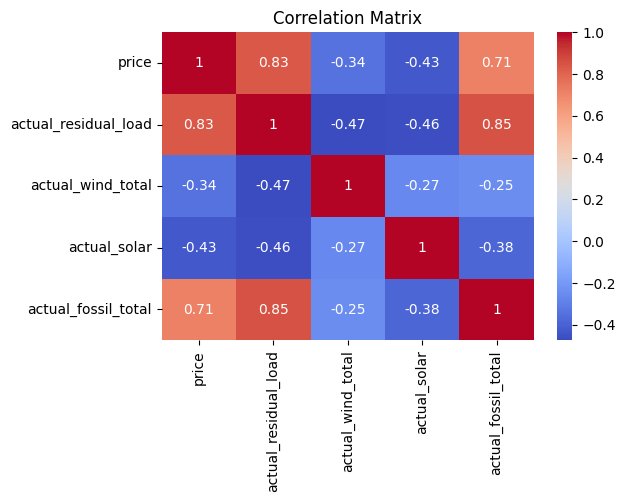

In [16]:
import seaborn as sns

cols = [
    "price",
    "actual_residual_load",
    "actual_wind_total",
    "actual_solar",
    "actual_fossil_total"
]

corr = df[cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()